# Capítulo 1 — Simulação de Dados
Este notebook descreve e executa a geração dos datasets sintéticos utilizados na pesquisa:
um arquivo Excel com registros de pagamentos a fornecedores e um XML no padrão NFS-e ABRASF
com notas fiscais de serviços eletrônicas.

In [1]:
from reconciliacao.utils.config import load_config
from reconciliacao.simulation.excel_generator import generate_payment_records, write_excel
from reconciliacao.simulation.xml_generator import generate_nfse, write_xml
import pandas as pd

cfg = load_config("../config.yaml")
sim = cfg["simulation"]

In [2]:
df_pag = generate_payment_records(sim["n_records"], sim["random_seed"])
write_excel(df_pag, "../data/raw/pagamentos.xlsx")
print(f"Registros de pagamento gerados: {len(df_pag)}")
df_pag.head(10)

Registros de pagamento gerados: 7500


,id_pagamento,cnpj_fornecedor,data_pagamento,valor_pago,descricao,centro_custo
0,PAG-000001,39660734467499,2026-02-17,18228.97,embrace proactive niches,CC-372
1,PAG-000002,46316460664987,2025-09-17,19451.62,enhance global platforms,CC-896
2,PAG-000003,65923002242290,2026-03-03,34954.64,extend e-business applications,CC-819
3,PAG-000004,42597657125419,2025-11-24,49828.67,integrate proactive infrastructures,CC-204
4,PAG-000005,39064847739286,2025-09-06,16377.06,enhance proactive schemas,CC-237
5,PAG-000006,15970996254315,2025-08-30,22684.86,unleash next-generation e-services,CC-515
6,PAG-000007,69420184457609,2025-12-05,17791.39,benchmark efficient synergies,CC-739
7,PAG-000008,93121510099986,2026-04-04,40120.44,exploit granular e-commerce,CC-134
8,PAG-000009,12082677345429,2025-10-24,12697.16,empower B2C e-tailers,CC-565
9,PAG-000010,88626395612626,2026-04-06,41363.18,facilitate sticky infrastructures,CC-470


In [3]:
df_nfse = generate_nfse(df_pag, sim["conciliation_rate"], sim["random_seed"])
write_xml(df_nfse, "../data/raw/nfse.xml")
print(f"NFS-e geradas: {len(df_nfse)}")
print(f"Conciliação esperada: {sim['conciliation_rate']*100:.0f}%")
df_nfse.head(10)

NFS-e geradas: 7500
Conciliação esperada: 70%


,nfse_numero,nfse_codigo_verificacao,nfse_data_emissao,nfse_competencia,nfse_cnpj_prestador,nfse_razao_social_prestador,nfse_cnpj_tomador,nfse_razao_social_tomador,nfse_valor_servicos,nfse_valor_iss,nfse_aliquota,nfse_valor_liquido,nfse_item_lista_servico,nfse_discriminacao,nfse_codigo_municipio
0,000001,WW8YL68N,2026-02-17T00:00:00,2026-02-01T00:00:00,39660734467499,Alves e Filhos,84085887704392,da Cruz,18228.97,858.58,4.71,17370.39,7.01,enhance global platforms,5300108
1,000002,1TWHWHY4,2025-09-17T00:00:00,2025-09-01T00:00:00,49316460664987,Pastor - ME,38612075011050,Alves S/A,19451.62,955.07,4.91,18496.55,1.03,architect bleeding-edge mindshare,4106902
2,000003,UIJNWPAY,2026-03-03T00:00:00,2026-03-01T00:00:00,65923002242290,Novais S.A.,80919015814429,Câmara,34954.64,1282.84,3.67,33671.80,1.02,grow efficient synergies,4106902
3,000004,POXRTEO2,2025-11-24T00:00:00,2025-11-01T00:00:00,42597657125419,Sampaio Lima Ltda.,84245088210090,Cassiano,49828.67,2142.63,4.30,47686.04,7.02,architect cross-platform platforms,5300108
4,000005,DH00H64F,2025-09-06T00:00:00,2025-09-01T00:00:00,39064847739286,Garcia S/A,23943129087820,Ferreira,16377.06,596.12,3.64,15780.94,1.02,expedite back-end paradigms,4106902
5,000006,JHU8MYIK,2025-08-30T00:00:00,2025-08-01T00:00:00,15970996254315,Nascimento,13577594929971,Garcia S/A,22684.86,911.93,4.02,21772.93,7.01,engage distributed functionalities,4106902
6,000007,RDXCK36H,2026-02-09T00:00:00,2026-02-01T00:00:00,20533645257726,Oliveira,11080996930866,Santos Azevedo S/A,22545.22,973.95,4.32,21571.27,1.05,repurpose bleeding-edge technologies,5300108
7,000008,TXFO6V4E,2026-04-04T00:00:00,2026-04-01T00:00:00,93121510099986,da Conceição S/A,88165803928220,da Mota,40120.44,1877.64,4.68,38242.80,14.01,target bricks-and-clicks communities,3304557
8,000009,8X80RMHR,2025-10-24T00:00:00,2025-10-01T00:00:00,12082677345429,Fogaça,14530385677006,Rios da Mata e Filhos,12697.16,322.51,2.54,12374.65,1.01,re-contextualize intuitive metrics,4106902
9,000010,8WJ0UUNN,2026-04-06T00:00:00,2026-04-01T00:00:00,88626395612626,Nascimento Siqueira S.A.,91846386557700,Martins Garcia Ltda.,41363.18,955.49,2.31,40407.69,1.01,re-contextualize magnetic methodologies,5300108


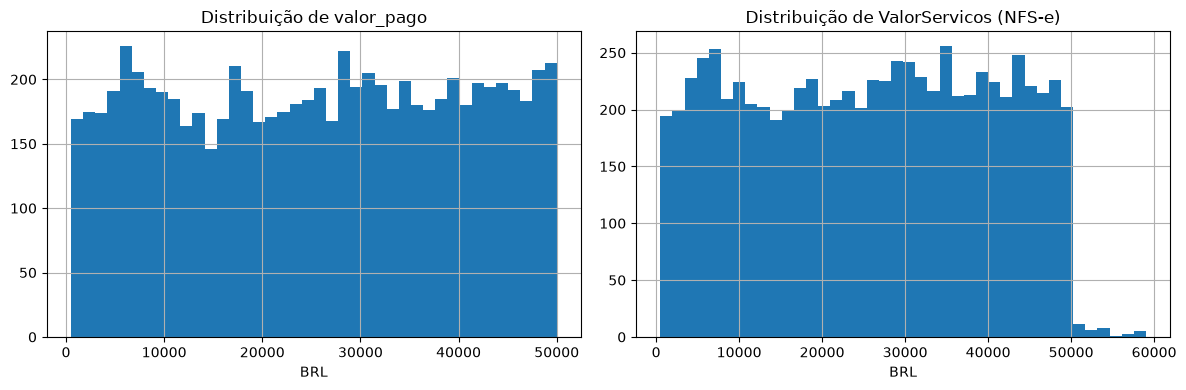

In [4]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
df_pag["valor_pago"].hist(bins=40, ax=axes[0])
axes[0].set_title("Distribuição de valor_pago")
axes[0].set_xlabel("BRL")
df_nfse["nfse_valor_servicos"].hist(bins=40, ax=axes[1])
axes[1].set_title("Distribuição de ValorServicos (NFS-e)")
axes[1].set_xlabel("BRL")
plt.tight_layout()
plt.show()